# 03 - Callaway-Sant'Anna Staggered DiD

TWFE with staggered treatment timing can be biased (Goodman-Bacon 2021):
already-treated units get used as comparisons for later-treated ones, and
their own evolving effects enter with negative weight. Callaway &
Sant'Anna (2021) fix this by estimating a separate 2x2 DiD for every
(cohort, period) cell and only aggregating valid comparisons.

`src/methods/callaway_santanna.py` implements this directly on numpy - no
R, and no `did` package. Inference is a pairs cluster bootstrap over
states.


In [ ]:
import sys
from pathlib import Path

# Walk up to the project root so the notebook runs from any working directory.
root = next(p for p in Path.cwd().resolve().parents if (p / "src").is_dir())
sys.path.insert(0, str(root))
# Data vintage: which raw inputs produced everything below. LAUS is
# revised, so an executed notebook has to carry its own provenance.
from src.data.manifest import format_manifest

print(format_manifest())


In [2]:
from src.data.loader import load_state_year_panel
from src.methods.callaway_santanna import estimate_att_gt

panel, is_synthetic = load_state_year_panel()
print(f"panel: {'synthetic' if is_synthetic else 'real'}, "
      f"{len(panel)} rows, {panel.state.nunique()} states, "
      f"{panel.year.min()}-{panel.year.max()}")

panel: real, 1173 rows, 51 states, 2000-2022


## Who is in the design

Never-treated states are the control group. States already above the
federal floor in the panel's first year have no clean pre-period and are
dropped.

In [3]:
never = panel[panel.adoption_year.isna()].state.nunique()
cohorts = (panel.dropna(subset=['adoption_year'])
           .drop_duplicates('state')
           .groupby('adoption_year').state.count())
first_year = int(panel.year.min())
always = int(cohorts.get(first_year, 0))

print(f'{never} never-treated (donors)')
print(f'{always} always-treated in {first_year} (no pre-period, dropped)')
print(f'{int(cohorts.sum()) - always} staggered adopters')
cohorts

14 never-treated (donors)
11 always-treated in 2000 (no pre-period, dropped)
26 staggered adopters


adoption_year
2000    11
2002     1
2004     1
2005     5
2006     4
2007    11
2008     1
2015     2
2021     1
Name: state, dtype: int64

## Group-time ATTs and their aggregations

In [4]:
result = estimate_att_gt(
    panel, aggregations=('simple', 'dynamic', 'group'), n_boot=500, seed=0
)
print(f"{result['n_units']} units in the design, "
      f"{result['n_boot']} bootstrap draws, "
      f"control group: {result['control_group']}")
if result['dropped_units']:
    print(f"dropped (no pre-period): {sorted(result['dropped_units'])}")

result['simple']

51 units in the design, 500 bootstrap draws, control group: nevertreated


,aggregation,att,se,ci_lower,ci_upper,band_lower,band_upper,n_cohorts,n_units
0,overall,0.523067,0.214523,0.102609,0.943524,0.091751,0.954382,8,26


The `simple` aggregation is the overall ATT: the average effect across
every treated state-year, in percentage points of unemployment.

In [5]:
result['group']  # one row per adoption cohort

,group,att,se,ci_lower,ci_upper,band_lower,band_upper,n_cohorts,n_units
0,2002.0,0.555414,0.168468,0.225222,0.885606,0.085246,1.025581,1,1
1,2004.0,0.209054,0.200676,-0.184265,0.602372,-0.351001,0.769109,1,1
2,2005.0,0.594788,0.334904,-0.061611,1.251188,-0.339873,1.529450,1,5
3,2006.0,1.196744,0.769117,-0.310698,2.704185,-0.949735,3.343223,1,4
4,2007.0,0.165527,0.236745,-0.298485,0.629539,-0.495190,0.826244,1,11
5,2008.0,1.425119,0.179857,1.072605,1.777633,0.923167,1.927071,1,1
6,2015.0,0.777455,0.251252,0.285011,1.269900,0.076252,1.478658,1,2
7,2021.0,-0.302976,0.176598,-0.649102,0.043150,-0.795833,0.189880,1,1


## Event-study aggregation

Negative event times are pre-treatment placebo cells. Under parallel
trends they should sit near zero - this is the same check the TWFE event
study in notebook 02 performs, but built from comparisons that never use
an already-treated state as a control.

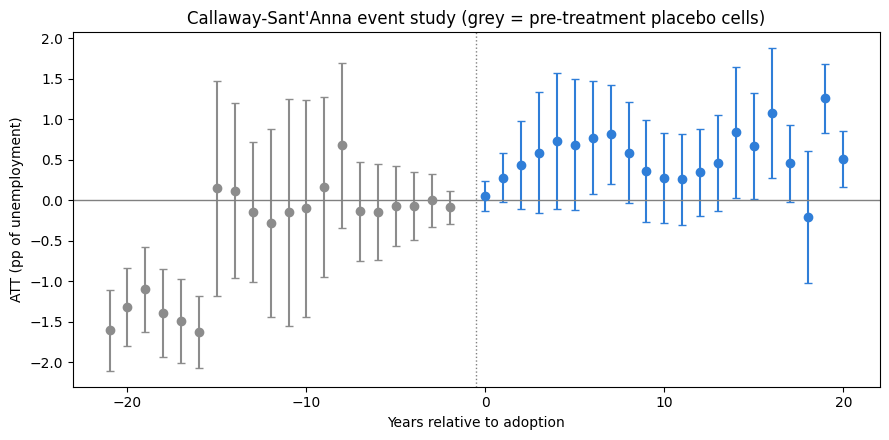

,event_time,att,se,ci_lower,ci_upper,band_lower,band_upper,n_cohorts,n_units
0,-21.0,-1.605357,0.253724,-2.102648,-1.108066,-2.403911,-0.806803,1,1
1,-20.0,-1.316071,0.246132,-1.798481,-0.833662,-2.090729,-0.541414,1,1
2,-19.0,-1.097024,0.267937,-1.622170,-0.571878,-1.940308,-0.253740,1,1
3,-18.0,-1.388690,0.275537,-1.928733,-0.848648,-2.255895,-0.521486,1,1
4,-17.0,-1.484524,0.264721,-2.003367,-0.965680,-2.317687,-0.651360,1,1
5,-16.0,-1.621429,0.227207,-2.066747,-1.176110,-2.336525,-0.906332,1,1
6,-15.0,0.149008,0.676511,-1.176930,1.474946,-1.980194,2.278210,2,3
7,-14.0,0.121230,0.549063,-0.954914,1.197374,-1.606852,1.849312,2,3
8,-13.0,-0.138294,0.441252,-1.003132,0.726544,-1.527058,1.250471,2,3
9,-12.0,-0.281151,0.590903,-1.439300,0.876998,-2.140917,1.578615,2,3


In [6]:
import matplotlib.pyplot as plt

event = result['dynamic']
fig, ax = plt.subplots(figsize=(9, 4.5))
pre = event[event.event_time < 0]
post = event[event.event_time >= 0]
for part, color in ((pre, '#8c8c8c'), (post, '#2f7ed8')):
    ax.errorbar(part.event_time, part.att,
                yerr=[part.att - part.ci_lower, part.ci_upper - part.att],
                fmt='o', capsize=3, color=color)
ax.axhline(0, color='gray', linewidth=1)
ax.axvline(-0.5, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Years relative to adoption')
ax.set_ylabel('ATT (pp of unemployment)')
ax.set_title("Callaway-Sant'Anna event study (grey = pre-treatment placebo cells)")
plt.tight_layout()
plt.show()

event

## Comparison to naive TWFE

If the two diverge, staggered-timing bias matters for this panel. Note
they are not on the same scale as-is: TWFE here is a semi-elasticity
(per log point of minimum wage), while Callaway-Sant'Anna estimates a
binary-treatment effect. `src/methods/comparison.py` handles that
conversion; notebook 05 uses it.

In [7]:
from src.methods.comparison import treated_log_wage_gap
from src.methods.twfe_did import estimate_twfe

twfe = estimate_twfe(panel)
factor = treated_log_wage_gap(panel)
twfe_converted = twfe.params['log_minimum_wage'] * factor
cs_att = result['simple'].att.iloc[0]

print(f'mean treated log wage gap:        {factor:.4f}')
print(f'TWFE semi-elasticity:             {twfe.params["log_minimum_wage"]:+.4f}')
print(f'TWFE, converted to pp:            {twfe_converted:+.4f}')
print(f"Callaway-Sant'Anna overall ATT:   {cs_att:+.4f}")
print(f'difference:                       {cs_att - twfe_converted:+.4f} pp')

mean treated log wage gap:        0.1736
TWFE semi-elasticity:             +0.5755
TWFE, converted to pp:            +0.0999
Callaway-Sant'Anna overall ATT:   +0.5231
difference:                       +0.4231 pp
